In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import unumpy as unp
from uncertainties import ufloat
import math
from scipy.stats import linregress
from scipy.optimize import curve_fit
from IPython.display import Markdown, HTML, Latex, display

$$\text{Anna Lechner, Paula Erhard}$$

# PW12 - Mechanische Schwingungen

## Harmonische Schwingungen - Pendelschwingungen

### Versuchsaufbau und Durchführung

Das Drehpendel wird mit konstanter Dämpfung betrieben, die über den Strom der Wirbelstrombremse eingestellt wird. Zur Untersuchung der freien gedämpften Schwingung bleibt der Motor ausgeschaltet. Das Pendel wird ausgelenkt und anschließend frei schwingen gelassen. Die Schwingungsdauer mehrerer Perioden sowie die zugehörigen Amplitudenmaxima werden gemessen. Zur Untersuchung der erzwungenen Schwingung wird der Motor eingeschaltet und die Erregerfrequenz im Bereich der Resonanz variiert. Nach dem Einschwingvorgang wird für jede Frequenz die stationäre Amplitude bestimmt.

### Wichtige Formeln und Zusammenhänge
Die gedämpfte Schwingung wird beschrieben durch  
$x(t) = x_0 \, e^{-\delta t} \cos(\omega_d t)$.

Die gedämpfte Kreisfrequenz ist  
$\omega_d = \sqrt{\omega_0^2 - \delta^2}$.

Die Dämpfungskonstante ergibt sich aus der Amplitudenabnahme:  
$\ln\!\left(\frac{x_i}{x_0}\right) = -\delta \, t_i$.

Die Halbwertsbreite der Resonanzkurve lautet  
$\Delta \omega = 2\delta$.

Die Güte des Oszillators ist  
$Q \approx \frac{\omega_0}{2\delta}$
$Q ≈ ω₀ / (2δ).$



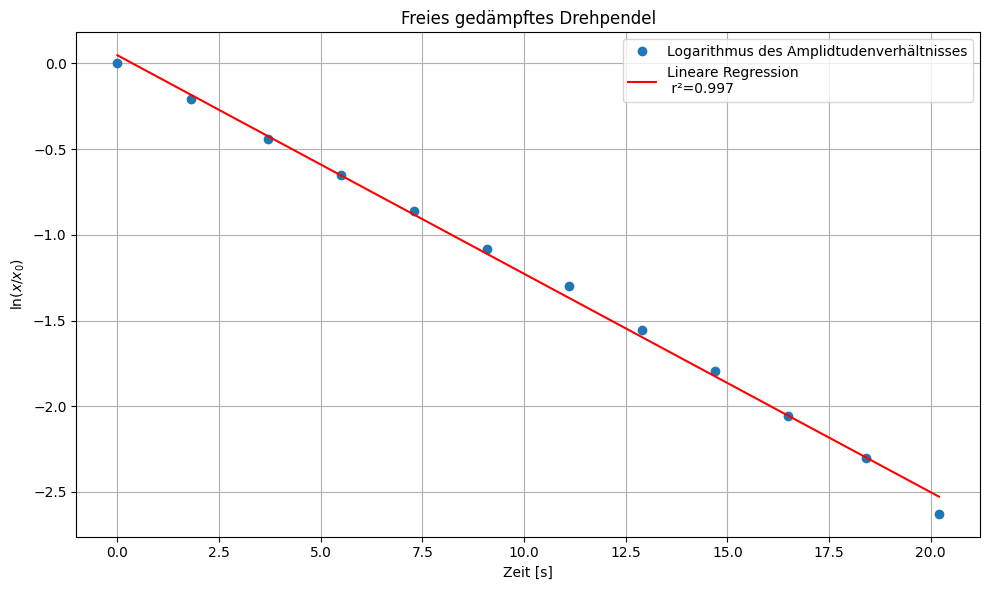

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

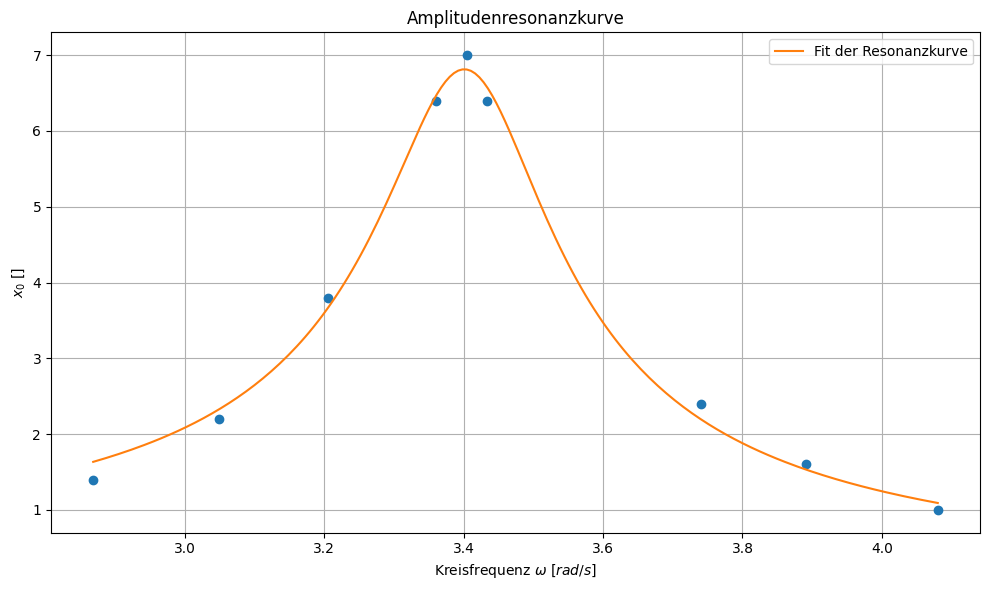

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [64]:
# 1. Experiment: Harmonische Schwingung

t = np.array([0, 1.8, 3.7, 5.5, 7.3, 9.1, 11.1, 12.9, 14.7, 16.5, 18.4, 20.2])    #Zeit [s]
x = np.array([18, 14.6, 11.6, 9.4, 7.6, 6.1, 4.9, 3.8, 3, 2.3, 1.8, 1.3])                           #Amplitude

# Dämpfungsstrom = 390mA

tu = unp.uarray(t, 0.2)     #mit Unsicherheit
xu = unp.uarray(x, 0.1)     #mit Unischerheit

T = t[-1]/len(t)        #Schwingungsdauer (Gesamtzeit durch Zahl der Schwingungen) [s]

w = 2*np.pi/ufloat(T,0.2)       #Kreisfrequenz [rad/s]

y = np.log(abs(x)/x[0])         #Logarithmus des amplituden Verhältnisses

res = linregress(t,y)

n= "\n"

#Plot
plt.figure(figsize=(10, 6))
plt.plot(t, y, "o", label="Logarithmus des Amplidtudenverhältnisses")
plt.plot(t, res.slope*t+res.intercept, "-r", label=f"Lineare Regression {n} r²={res.rvalue**2:.3f}")
plt.ylabel(r"$\ln(x/x_0)$")
plt.xlabel(r"Zeit [s]")
plt.legend()
plt.title("Freies gedämpftes Drehpendel")
plt.tight_layout()
plt.grid()
plt.show()

display(Latex(fr"$$\omega_d = ({w:.2f}) ~ \mathrm rad/s$$"))      #Kreisfrquenz der gedämpften Schwingung [rad/s]

display(Latex(fr"$$\delta = ({abs(res.slope):.3f} \pm {res.stderr:.3f}) ~ \mathrm 1/s$$"))      #Dämpfungskonstante [1/s]

w0 = unp.sqrt(ufloat(abs(res.slope), res.stderr)**2 + w**2)     #Eigenfrequenz [rad/s]

display(Latex(fr"$$\omega_0 = ({w0:.3f}) ~ \mathrm rad/s$$"))                     #Eigenfrequenz [rad/s]

display(Latex(fr"$$Q_{{frei}} = {w0/(2*ufloat(abs(res.slope), res.stderr)):.3f}$$"))           #Gütefaktor freie Schwingung






# Getriebener 

w0 = unp.nominal_values(w0)         #Eigenfrequenz [rad/s] (wert von vorher ohne unsicherheit)


#Tl = np.array([18.4, 18.01, 19.06, 15.17, 21.86, 21.28, 19.67, 19.14, 17.1, 17.56])/10
#x0l = np.array([6.2,5.8,5.4, 0.8, 1.4, 1.6, 3.2, 4, 2.2, 3.2])
T = np.array([ 18.45, 18.3, 16.8, 16.15, 15.4, 20.6, 18.7, 19.6, 21.9])/10       #Schwingungsdauer ? [s?]
x0 = np.array([ 7, 6.4, 2.4, 1.6, 1, 2.2, 6.4, 3.8, 1.4])
#rot= np.array([195, 220, 265, 300, 320, 330, 335, 345, 375, 390, 415])/10        #[1/min]

#f = rot/60             #frequenz [Hz]
f = 1/T

#x0 = np.array([0.8, 1, 1.6, 2.6, 5.6, 7, 4.6, 3.2, 1.6, 1.2, 0.8])               #Amplituden

w = f * np.pi * 2       #Kreisfrequenz [rad/s]

w0 = w[0]

def resonanz(w, a, delta):          #fit funktion für resonanzkurve
    return (a) / np.sqrt((unp.nominal_values(w0)**2 - w**2)**2 + 4*(delta**2)*(w**2))

p0= [2, 0.1]            #anfangsdaten für fit

res, pcov = curve_fit(resonanz, w, x0, p0=p0)       #fit

a, delta_fit = res
a_err, delta_err = np.sqrt(np.diag(pcov))


w_fit = np.linspace(min(w),max(w),200)

plt.figure(figsize=(10, 6))
plt.plot(w, x0, "o")
plt.plot(w_fit,resonanz(w_fit, a, delta_fit), "-", label="Fit der Resonanzkurve")
plt.ylabel(r"$x_0$ $[]$")
plt.xlabel(r"Kreisfrequenz $\omega~[rad/s]$")
plt.legend()
plt.title("Amplitudenresonanzkurve")
plt.tight_layout()
plt.grid()
plt.show()


display(Latex(fr"$$\delta = ({delta_fit:.3f} \pm {delta_err:.3f}) ~ \mathrm 1/s$$"))        #Dämpfungskonstante [1/s]

display(Latex(fr"$$Q_{{erzwungen}} = {w0/(2*ufloat(delta_fit, delta_err)):.3f}$$"))         #GÜtefaktor

### Diskussion

Die Resonanzfrequenz $\omega_0$ des Drehpendels liegt bei ca. 3,75 rad/s. Die Dämpfungskonstante $\delta$ liegt bei einem Dämpfungsstrom von 390mA bei ca. 0.128/s. Der Gütefaktor der freien und erzwungegen Schwingung liegt jeweils im Unsicherheisbereich der anderen hat hat einen Wert von ca. 14,6 bzw. 14,1.

Im ersten Teil des Experiments wird der logarithmische Zusammenhang gefittet, da sich so ein lineare Regressionsfunktion ergibt und Fehler nicht exponentiell mit einbezogen werden.

## Gekoppelte Schwingungen

### Versuchsaufbau und Durchführung
Zwei Pendel werden über ein Kopplungsgewicht miteinander verbunden. Zur Erzeugung einer Schwebung wird ein Pendel ausgelenkt, während das zweite in Ruhelage verbleibt. Die relevanten Schwingungsdauern werden gemessen und daraus die Eigenfrequenzen bestimmt. Aus diesen wird der Kopplungsgrad berechnet.

### Wichtige Formeln und Zusammenhänge
Die Eigenfrequenzen des Systems sind  
$\omega_0 = \sqrt{\frac{D}{J}}$  
und  
$\omega_1 = \sqrt{\frac{D + 2D^\ast}{J}}$.

Die Schwebungsfrequenz ist  
$\omega_S = \frac{\omega_1 - \omega_0}{2}$.

Der Kopplungsgrad ergibt sich zu  
$K = \frac{\omega_1^2 - \omega_0^2}{\omega_1^2 + \omega_0^2}$.





In [65]:
# 2. Experiment: Gekoppelte Schwingungen

# Gleichsinnig

# L = (86 \pm 1)cm

# l = (49 \pm 1)cm


# w_gl = (1/17.72/10)*2*np.pi

# w_geg = (1/16.81/10)*2*np.pi


w_s = np.pi/(ufloat(42.23,1))                    #Schwebungsfrequenz

w_2 = (2* np.pi)/(ufloat(7.68,1)/5)      #Schwingungsfrequenz ein pendel


w1 = w_s + w_2

w0 = w_2 - w_s

K = 2*w_s*w_2/(w_2**2+w_s**2)

display(Latex(rf"$$l = 40 \pm 0.1  ~ \mathrm cm$$"))

display(Latex(rf"$$\omega_s = ({w_s:.4f}) ~ \mathrm rad/s$$"))
display(Latex(rf"$$\omega_2 = ({w_2:.2f}) ~ \mathrm rad/s$$"))


# display(Latex(rf"$$\omega_{{gl}} = {w_gl:.2f}$$"))
# display(Latex(rf"$$\omega_{{geg}} = {w_geg:.2f}$$"))

display(Latex(rf"$$\omega_0 = ({w0:.2f}) ~ \mathrm rad/s$$"))
display(Latex(rf"$$\omega_1 = ({w1:.2f}) ~ \mathrm rad/s$$"))

display(Latex(rf"$$K = {K:.3f}$$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Diskussion

Die Schwebungsfrequenz $\omega_s$ des gekoppelten Pendels mit eine Kopplungslänge von 40 cm ist ca. 0,074 rad/s.
Mit $\omega_2$ von ca. 4,02 rad/s ergibt sich ein Kopplungsgrad K von 0,036.

Durch die geringe Koppling liegen die Eigenfrequenzen $\omega_0$ und $\omega_1$ der beiden Pendel sehr nahe beieinander. Der Mittelwert dieser beiden ist $\omega_2$